In [3]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
import umap

# Mismas constantes que dataset.py
_KEEP_IDX = list(range(0, 17)) + list(range(91, 133))  # 59 landmarks
SCORE_THRESH = 0.3

/lustre/home/estudiante_27/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
def preprocess(kpts: np.ndarray, score_thresh: float = 0.3) -> np.ndarray:
    """(T, 133, 3) → vector aplanado (59*2,) float32 — promedio temporal."""
    kpts = kpts[:, _KEEP_IDX, :]        # (T, 59, 3)
    xy     = kpts[:, :, :2].copy()
    scores = kpts[:, :, 2]
    xy[scores < score_thresh] = 0.0

    shoulder_mid = (xy[:, 5, :] + xy[:, 6, :]) / 2.0
    xy -= shoulder_mid[:, None, :]

    hip_mid = (xy[:, 11, :] + xy[:, 12, :]) / 2.0
    scale   = np.linalg.norm(hip_mid, axis=-1).clip(1e-8)
    xy     /= scale[:, None, None]

    # Colapsar dimensión temporal: promedio sobre frames
    return xy.mean(axis=0).reshape(-1).astype(np.float32)   # (118,)


df = pd.read_parquet("../corpus_LSM_esp/lsm_dataset.parquet").reset_index(drop=True)

print(f"Cargando {len(df)} videos...")
vectors, glosas, speakers = [], [], []

for _, row in df.iterrows():
    kpts = np.load(io.BytesIO(row["keypoints"]))        # (T, 133, 3)
    vectors.append(preprocess(kpts, SCORE_THRESH))
    glosas.append(row["glosa"])
    speakers.append(str(row["intento"]).zfill(5)[:2])

X       = np.stack(vectors)                             # (N, 118)
glosas  = np.array(glosas)
speakers = np.array(speakers)

print(f"Matriz de entrada: {X.shape}")
print(f"Glosas únicas: {len(np.unique(glosas))}")
print(f"Señantes únicos: {sorted(np.unique(speakers))}")

Cargando 2447 videos...
Matriz de entrada: (2447, 118)
Glosas únicas: 249
Señantes únicos: [np.str_('01'), np.str_('02'), np.str_('03'), np.str_('04'), np.str_('05'), np.str_('06'), np.str_('07'), np.str_('08'), np.str_('09'), np.str_('10'), np.str_('11')]


In [6]:
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="euclidean",
    random_state=42,
    verbose=True,
)

embedding = reducer.fit_transform(X)    # (N, 2)
print(f"Embedding shape: {embedding.shape}")

/lustre/home/estudiante_27/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(n_jobs=1, random_state=42, verbose=True)
Wed Mar 18 14:18:59 2026 Construct fuzzy simplicial set
Wed Mar 18 14:19:01 2026 Finding Nearest Neighbors
Wed Mar 18 14:19:05 2026 Finished Nearest Neighbor Search
Wed Mar 18 14:19:07 2026 Construct embedding


Epochs completed:   6%| ▌          29/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs


Epochs completed:  27%| ██▋        133/500 [00:01]

...

	completed  300  /  500 epochs
	completed  350  /  500 epochs


Epochs completed:  89%| ████████▉  445/500 [00:02]

	completed  400  /  500 epochs
	completed  450  /  500 epochs


Epochs completed: 100%| ██████████ 500/500 [00:02]

Wed Mar 18 14:19:09 2026 Finished embedding
Embedding shape: (2447, 2)


/tmp/ipykernel_1521135/627859557.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = cm.get_cmap("turbo", n_clases)


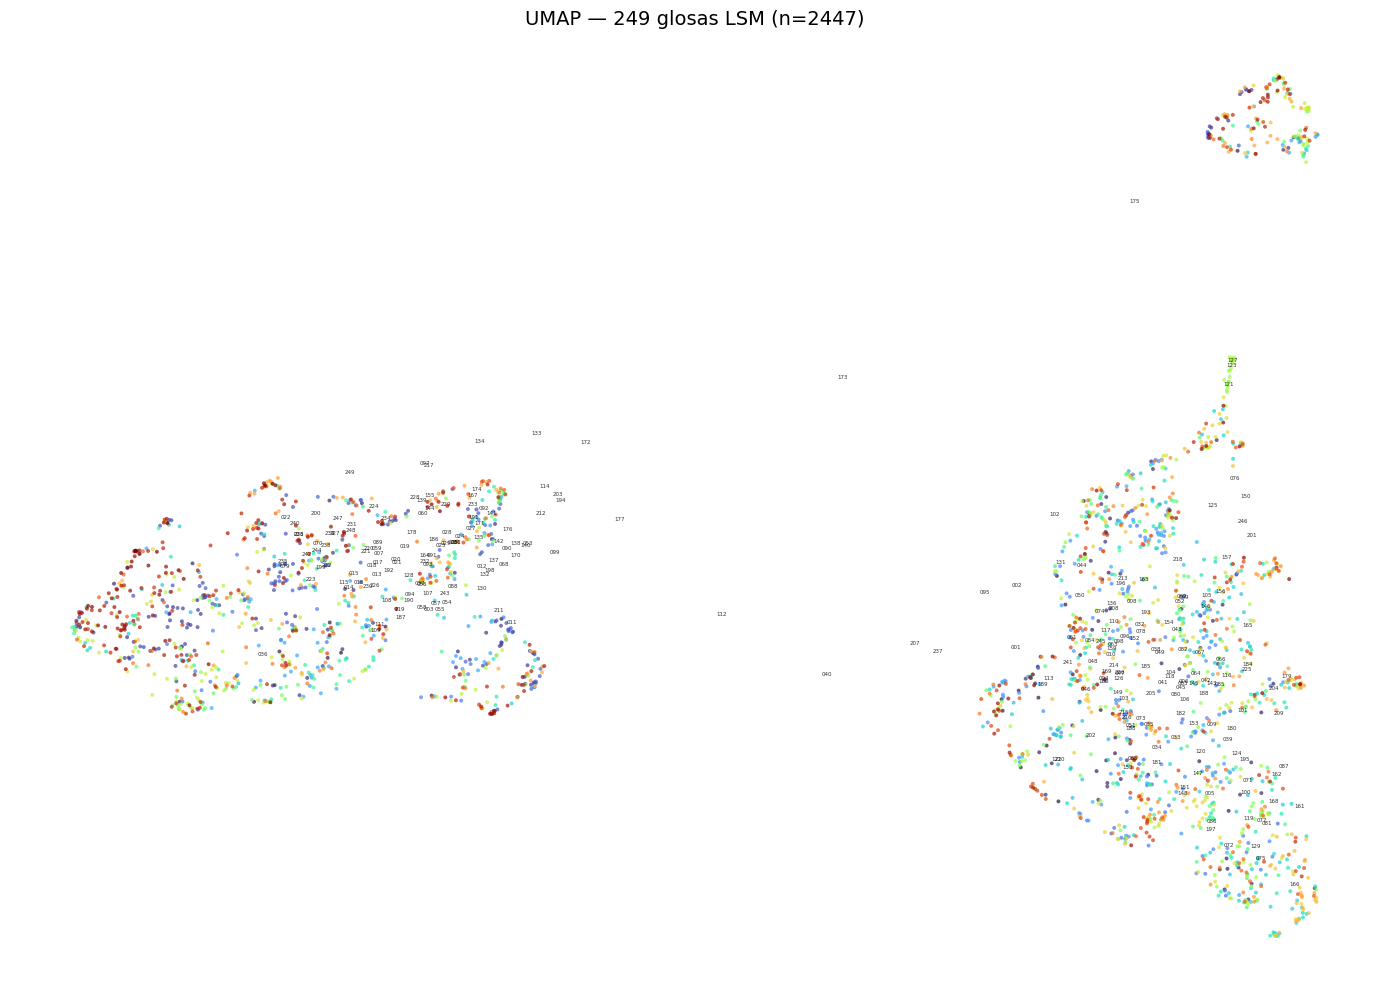

Guardado: umap_glosas.png


In [7]:
glosas_uniq = sorted(np.unique(glosas))
n_clases    = len(glosas_uniq)
glosa2idx   = {g: i for i, g in enumerate(glosas_uniq)}
labels_idx  = np.array([glosa2idx[g] for g in glosas])

cmap   = cm.get_cmap("turbo", n_clases)
colors = cmap(labels_idx / n_clases)

fig, ax = plt.subplots(figsize=(14, 10))
scatter = ax.scatter(
    embedding[:, 0], embedding[:, 1],
    c=colors, s=8, alpha=0.7, linewidths=0,
)
ax.set_title(f"UMAP — {n_clases} glosas LSM (n={len(X)})", fontsize=14)
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.axis("off")

# Anotar centroide de cada glosa
for g, idx in glosa2idx.items():
    mask = labels_idx == idx
    if mask.sum() == 0:
        continue
    cx, cy = embedding[mask, 0].mean(), embedding[mask, 1].mean()
    ax.text(cx, cy, g, fontsize=4, ha="center", va="center", alpha=0.8)

plt.tight_layout()
plt.savefig("./umap/umap_glosas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: umap_glosas.png")

/tmp/ipykernel_1521135/457432728.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_sp = cm.get_cmap("tab20", n_speakers)


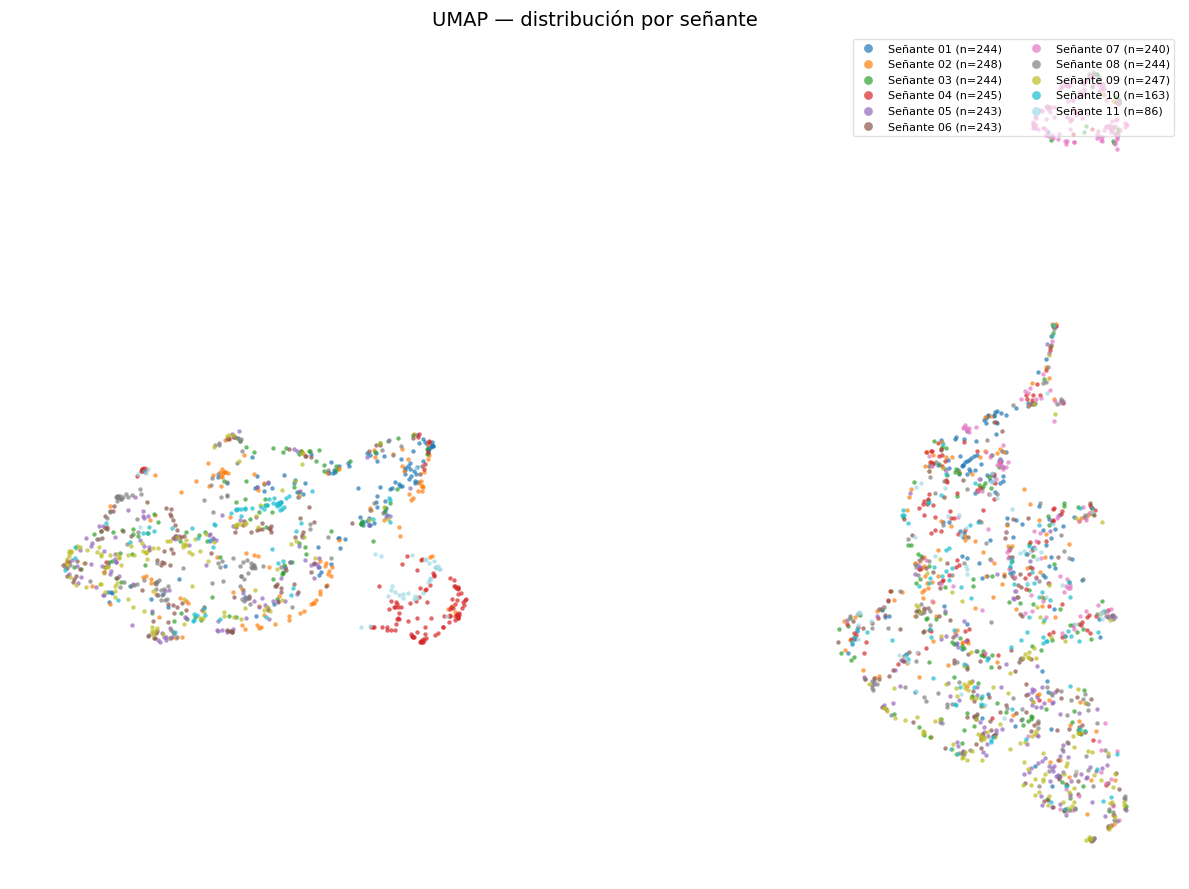

Guardado: umap_senantes.png


In [8]:
speakers_uniq = sorted(np.unique(speakers))
n_speakers    = len(speakers_uniq)
sp2idx        = {s: i for i, s in enumerate(speakers_uniq)}
sp_idx        = np.array([sp2idx[s] for s in speakers])

cmap_sp = cm.get_cmap("tab20", n_speakers)

fig, ax = plt.subplots(figsize=(12, 9))
for i, sp in enumerate(speakers_uniq):
    mask = sp_idx == i
    ax.scatter(
        embedding[mask, 0], embedding[mask, 1],
        c=[cmap_sp(i)], s=10, alpha=0.7,
        linewidths=0, label=f"Señante {sp} (n={mask.sum()})",
    )

ax.set_title("UMAP — distribución por señante", fontsize=14)
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.axis("off")
ax.legend(
    loc="upper right", markerscale=2,
    fontsize=8, framealpha=0.6,
    ncol=2,
)
plt.tight_layout()
plt.savefig("./umap/umap_senantes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: umap_senantes.png")

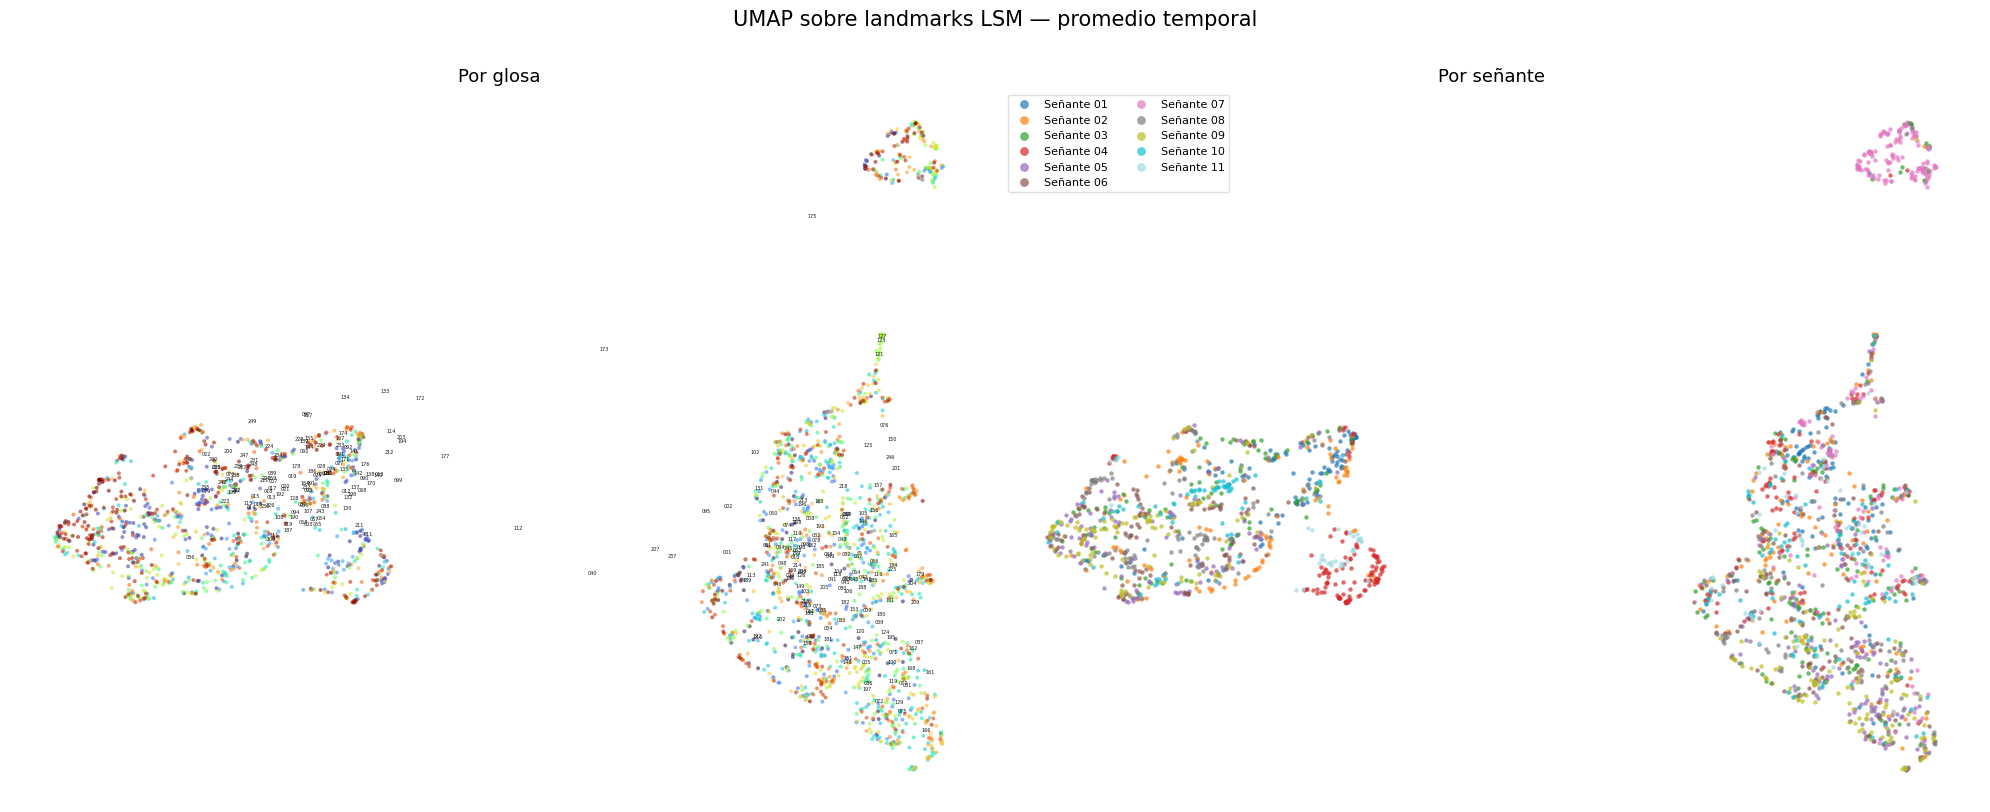

Guardado: umap_combinado.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# — Izquierda: por glosa ——————————————————————————————————————————————————————
axes[0].scatter(
    embedding[:, 0], embedding[:, 1],
    c=labels_idx, cmap="turbo", s=8, alpha=0.6, linewidths=0,
)
for g, idx in glosa2idx.items():
    mask = labels_idx == idx
    if mask.sum() == 0:
        continue
    cx, cy = embedding[mask, 0].mean(), embedding[mask, 1].mean()
    axes[0].text(cx, cy, g, fontsize=3.5, ha="center", va="center", alpha=0.9)
axes[0].set_title("Por glosa", fontsize=13)
axes[0].axis("off")

# — Derecha: por señante ——————————————————————————————————————————————————————
for i, sp in enumerate(speakers_uniq):
    mask = sp_idx == i
    axes[1].scatter(
        embedding[mask, 0], embedding[mask, 1],
        c=[cmap_sp(i)], s=10, alpha=0.7,
        linewidths=0, label=f"Señante {sp}",
    )
axes[1].set_title("Por señante", fontsize=13)
axes[1].axis("off")
axes[1].legend(fontsize=8, markerscale=2, ncol=2, framealpha=0.6)

fig.suptitle("UMAP sobre landmarks LSM — promedio temporal", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("./umap/umap_combinado.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: umap_combinado.png")

In [11]:
# Celda nueva — identificar el outlier
from scipy.spatial.distance import cdist

centroid = embedding.mean(axis=0)
dist_to_center = np.linalg.norm(embedding - centroid, axis=1)

# Los puntos más alejados del centroide
outlier_thresh = np.percentile(dist_to_center, 95)
outlier_mask   = dist_to_center > outlier_thresh

print("Distribución de señantes en outliers:")
print(pd.Series(speakers[outlier_mask]).value_counts())

print("\nDistribución de glosas en outliers:")
print(pd.Series(glosas[outlier_mask]).value_counts().head(20))

Distribución de señantes en outliers:
07    35
09    24
05    18
06    16
03    14
08     8
02     4
10     3
04     1
Name: count, dtype: int64

Distribución de glosas en outliers:
134    7
079    7
007    4
133    4
097    4
139    4
238    4
217    4
155    3
228    3
234    3
231    3
244    3
240    3
239    3
248    3
144    3
223    3
142    3
023    3
Name: count, dtype: int64


In [12]:
# Celda — inspeccionar las glosas outlier
glosas_outlier = pd.Series(glosas[outlier_mask]).value_counts()
glosas_outlier_top = glosas_outlier[glosas_outlier >= 3].index.tolist()

print("Glosas consistentemente en el outlier (≥3 señantes):")
print(glosas_outlier_top)

# Ver cuántos videos tiene cada una y su representación en splits
for g in glosas_outlier_top:
    mask_g = glosas == g
    sps = np.unique(speakers[mask_g])
    print(f"  Glosa {g}: {mask_g.sum()} videos, señantes: {sorted(sps)}")

Glosas consistentemente en el outlier (≥3 señantes):
['134', '079', '007', '133', '097', '139', '238', '217', '155', '228', '234', '231', '244', '240', '239', '248', '144', '223', '142', '023']
  Glosa 134: 10 videos, señantes: [np.str_('01'), np.str_('02'), np.str_('03'), np.str_('04'), np.str_('05'), np.str_('06'), np.str_('07'), np.str_('08'), np.str_('09'), np.str_('10')]
  Glosa 079: 11 videos, señantes: [np.str_('01'), np.str_('02'), np.str_('03'), np.str_('04'), np.str_('05'), np.str_('06'), np.str_('07'), np.str_('08'), np.str_('09'), np.str_('10'), np.str_('11')]
  Glosa 007: 11 videos, señantes: [np.str_('01'), np.str_('02'), np.str_('03'), np.str_('04'), np.str_('05'), np.str_('06'), np.str_('07'), np.str_('08'), np.str_('09'), np.str_('10'), np.str_('11')]
  Glosa 133: 10 videos, señantes: [np.str_('01'), np.str_('02'), np.str_('03'), np.str_('04'), np.str_('05'), np.str_('06'), np.str_('07'), np.str_('08'), np.str_('09'), np.str_('10')]
  Glosa 097: 10 videos, señantes: [n

/tmp/ipykernel_1521135/3687049495.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_out = cm.get_cmap("tab20", len(glosas_outlier_top))


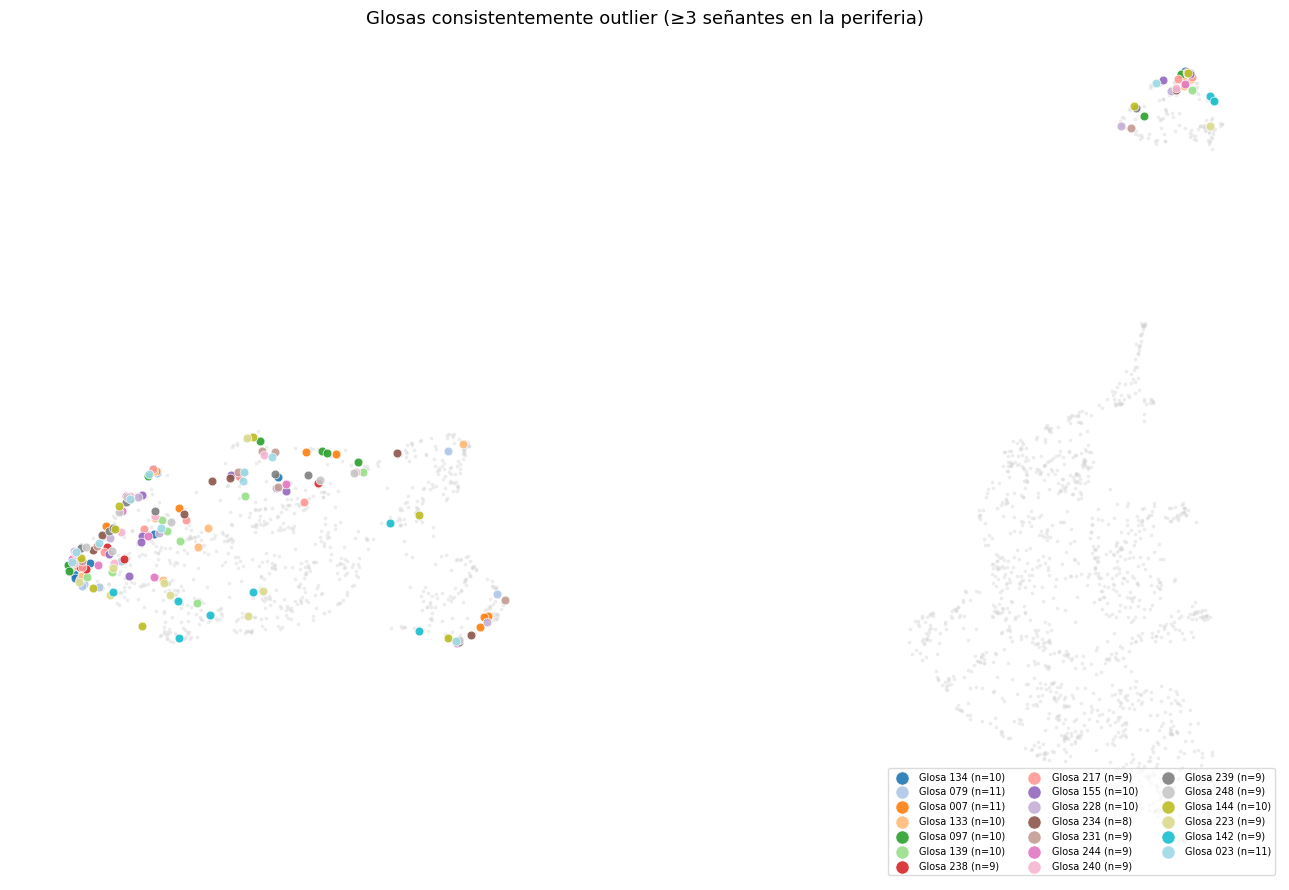

In [13]:
# Celda — UMAP coloreando solo las glosas outlier vs el resto
fig, ax = plt.subplots(figsize=(13, 9))

# Fondo: todos los puntos en gris
ax.scatter(embedding[:, 0], embedding[:, 1],
           c="lightgray", s=7, alpha=0.4, linewidths=0, zorder=1)

# Encima: glosas outlier con color propio
cmap_out = cm.get_cmap("tab20", len(glosas_outlier_top))
for i, g in enumerate(glosas_outlier_top):
    mask_g = glosas == g
    ax.scatter(embedding[mask_g, 0], embedding[mask_g, 1],
               c=[cmap_out(i)], s=40, alpha=0.9,
               linewidths=0.5, edgecolors="white",
               label=f"Glosa {g} (n={mask_g.sum()})", zorder=2)

ax.set_title("Glosas consistentemente outlier (≥3 señantes en la periferia)", fontsize=13)
ax.axis("off")
ax.legend(fontsize=7, ncol=3, framealpha=0.7,
          loc="lower right", markerscale=1.5)
plt.tight_layout()
plt.savefig("umap_outlier_glosas.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# Celda — comparar postura media de glosas outlier vs resto
# Útil para entender QUÉ las hace distintas espacialmente

print("Postura media (primeras 6 coords = hombros+codos) por grupo:\n")

mask_out  = np.isin(glosas, glosas_outlier_top)
mask_rest = ~mask_out

mean_out  = X[mask_out].mean(axis=0)
mean_rest = X[mask_rest].mean(axis=0)
diff      = np.abs(mean_out - mean_rest).reshape(59, 2)

# Top landmarks con mayor diferencia
diff_norm = np.linalg.norm(diff, axis=1)   # (59,) — magnitud por landmark

# Mapear de vuelta a índices originales
_KEEP_IDX = list(range(0, 17)) + list(range(91, 133))
top_landmarks = np.argsort(diff_norm)[::-1][:10]

print("Top 10 landmarks con mayor diferencia outlier vs resto:")
for rank, li in enumerate(top_landmarks):
    orig_idx = _KEEP_IDX[li]
    region   = "cuerpo" if orig_idx < 17 else "mano_izq" if orig_idx < 112 else "mano_der"
    print(f"  {rank+1}. landmark filtrado {li:2d} "
          f"(original {orig_idx:3d}, {region}) — Δ={diff_norm[li]:.4f}")

Postura media (primeras 6 coords = hombros+codos) por grupo:

Top 10 landmarks con mayor diferencia outlier vs resto:
  1. landmark filtrado 23 (original  97, mano_izq) — Δ=0.2600
  2. landmark filtrado 24 (original  98, mano_izq) — Δ=0.2592
  3. landmark filtrado 27 (original 101, mano_izq) — Δ=0.2544
  4. landmark filtrado 25 (original  99, mano_izq) — Δ=0.2537
  5. landmark filtrado 28 (original 102, mano_izq) — Δ=0.2522
  6. landmark filtrado 21 (original  95, mano_izq) — Δ=0.2512
  7. landmark filtrado 29 (original 103, mano_izq) — Δ=0.2497
  8. landmark filtrado 22 (original  96, mano_izq) — Δ=0.2486
  9. landmark filtrado 31 (original 105, mano_izq) — Δ=0.2462
  10. landmark filtrado 26 (original 100, mano_izq) — Δ=0.2450


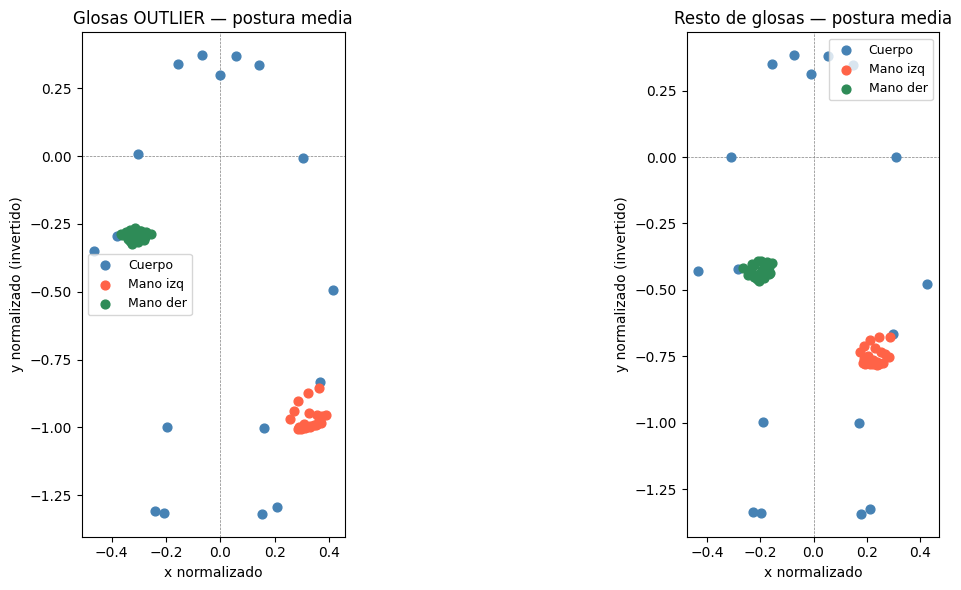

In [15]:
# Celda — visualizar dónde está la mano izquierda en outliers vs resto
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Índices en el array filtrado para mano izquierda (posiciones 17-37)
hand_l_idx = list(range(17, 38))   # 21 kpts mano izq en array filtrado

# Postura media 2D: (59, 2)
mean_out_2d  = X[mask_out].mean(axis=0).reshape(59, 2)
mean_rest_2d = X[mask_rest].mean(axis=0).reshape(59, 2)

body_idx  = list(range(0, 17))     # cuerpo
hand_l    = list(range(17, 38))    # mano izq
hand_r    = list(range(38, 59))    # mano der

for ax, mean_2d, title in zip(
    axes,
    [mean_out_2d, mean_rest_2d],
    ["Glosas OUTLIER — postura media", "Resto de glosas — postura media"]
):
    ax.scatter(mean_2d[body_idx, 0],  -mean_2d[body_idx, 1],
               c="steelblue", s=40, label="Cuerpo", zorder=3)
    ax.scatter(mean_2d[hand_l, 0],   -mean_2d[hand_l, 1],
               c="tomato", s=40, label="Mano izq", zorder=3)
    ax.scatter(mean_2d[hand_r, 0],   -mean_2d[hand_r, 1],
               c="seagreen", s=40, label="Mano der", zorder=3)
    ax.set_title(title, fontsize=12)
    ax.set_aspect("equal")
    ax.legend(fontsize=9)
    ax.axhline(0, color="gray", lw=0.5, ls="--")
    ax.axvline(0, color="gray", lw=0.5, ls="--")
    ax.set_xlabel("x normalizado")
    ax.set_ylabel("y normalizado (invertido)")

plt.tight_layout()
plt.savefig("postura_outlier_vs_resto.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
# Celda — verificar cobertura de glosas outlier en cada split
df["_speaker"] = df["intento"].astype(str).str.zfill(5).str[:2]

val_speakers  = ["08"]
test_speakers = ["09"]
train_speakers = [s for s in df["_speaker"].unique()
                  if s not in val_speakers + test_speakers]

print(f"{'Glosa':>8} | {'train':>6} | {'val':>5} | {'test':>5}")
print("-" * 32)
for g in sorted(glosas_outlier_top):
    sub = df[df["glosa"] == g]
    n_train = sub[sub["_speaker"].isin(train_speakers)].shape[0]
    n_val   = sub[sub["_speaker"].isin(val_speakers)].shape[0]
    n_test  = sub[sub["_speaker"].isin(test_speakers)].shape[0]
    flag = " ⚠" if n_val == 0 or n_test == 0 else ""
    print(f"  {g:>6} | {n_train:>6} | {n_val:>5} | {n_test:>5}{flag}")

   Glosa |  train |   val |  test
--------------------------------
     007 |      9 |     1 |     1
     023 |      9 |     1 |     1
     079 |      9 |     1 |     1
     097 |      8 |     1 |     1
     133 |      8 |     1 |     1
     134 |      8 |     1 |     1
     139 |      8 |     1 |     1
     142 |      7 |     1 |     1
     144 |      8 |     1 |     1
     155 |      8 |     1 |     1
     217 |      7 |     1 |     1
     223 |      7 |     1 |     1
     228 |      8 |     1 |     1
     231 |      7 |     1 |     1
     234 |      6 |     1 |     1
     238 |      7 |     1 |     1
     239 |      7 |     1 |     1
     240 |      7 |     1 |     1
     244 |      7 |     1 |     1
     248 |      7 |     1 |     1


In [17]:
# Celda — distancia de cada señante al centroide de su glosa

records = []

for g in sorted(np.unique(glosas)):
    mask_g  = glosas == g
    X_g     = X[mask_g]           # (n_señantes, 118)
    sps_g   = speakers[mask_g]
    emb_g   = embedding[mask_g]   # (n_señantes, 2) — para visualización

    if len(X_g) < 3:              # skip glosas con muy pocos videos
        continue

    centroid   = X_g.mean(axis=0)                                    # (118,)
    dists      = np.linalg.norm(X_g - centroid, axis=1)              # (n,)
    mean_d     = dists.mean()
    std_d      = dists.std()

    for i, (sp, d) in enumerate(zip(sps_g, dists)):
        z = (d - mean_d) / (std_d + 1e-8)
        records.append({
            "glosa":    g,
            "speaker":  sp,
            "dist":     d,
            "mean_d":   mean_d,
            "std_d":    std_d,
            "z_score":  z,
        })

df_outliers = pd.DataFrame(records)
print(f"Total registros: {len(df_outliers)}")
print(df_outliers.sort_values("z_score", ascending=False).head(10).to_string(index=False))

Total registros: 2447
glosa speaker     dist   mean_d    std_d  z_score
  070      07 6.213686 1.457600 1.523409 3.122002
  068      07 5.007435 1.126311 1.248508 3.108609
  018      07 5.750380 1.501398 1.374035 3.092340
  055      07 5.177454 1.176232 1.294454 3.091049
  016      07 5.954302 1.545727 1.426703 3.090043
  030      07 3.962018 1.234164 0.882848 3.089834
  014      07 5.444461 1.486736 1.284726 3.080600
  088      07 4.948429 1.253441 1.199562 3.080281
  054      07 5.010718 1.314602 1.200641 3.078454
  013      07 5.138333 1.374683 1.225232 3.071786


In [18]:
# Celda — ranking global de señantes más "raros" por glosa

Z_THRESH = 2.0   # ajustable

flagged = df_outliers[df_outliers["z_score"] > Z_THRESH].copy()
flagged = flagged.sort_values("z_score", ascending=False)

print(f"Pares (glosa, señante) con z > {Z_THRESH}: {len(flagged)}\n")
print(flagged[["glosa", "speaker", "dist", "z_score"]].to_string(index=False))

Pares (glosa, señante) con z > 2.0: 172

glosa speaker     dist  z_score
  070      07 6.213686 3.122002
  068      07 5.007435 3.108609
  018      07 5.750380 3.092340
  055      07 5.177454 3.091049
  016      07 5.954302 3.090043
  030      07 3.962018 3.089834
  014      07 5.444461 3.080600
  088      07 4.948429 3.080281
  054      07 5.010718 3.078454
  013      07 5.138333 3.071786
  056      07 4.721141 3.070111
  057      07 4.792568 3.066683
  031      07 4.383586 3.065807
  003      07 5.412491 3.060507
  015      07 5.769551 3.060315
  023      07 6.166162 3.059367
  022      07 5.843328 3.049793
  017      07 5.323702 3.045613
  053      07 4.446368 3.038275
  019      07 5.555429 3.034688
  025      07 4.446829 3.034500
  007      07 7.725578 3.033664
  037      07 5.195323 3.020157
  058      07 5.040298 3.013818
  090      07 4.661718 3.011453
  089      07 5.876127 3.005788
  020      07 5.265491 2.997738
  026      07 4.389561 2.996685
  029      07 4.126262 2.987272

In [19]:
# Celda — resumen por señante: cuántas glosas hace "raro"

resumen = (
    flagged.groupby("speaker")
    .agg(
        n_glosas_outlier=("glosa", "count"),
        z_medio=("z_score", "mean"),
        z_max=("z_score", "max"),
        glosas=("glosa", lambda x: sorted(x.tolist())),
    )
    .sort_values("n_glosas_outlier", ascending=False)
    .reset_index()
)
print("Señantes con más glosas fuera de norma:\n")
print(resumen.to_string(index=False))

Señantes con más glosas fuera de norma:

speaker  n_glosas_outlier  z_medio    z_max                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    glosas
     07               123 2.744149 3.122002 [001, 002, 003, 007, 010, 011, 012, 013, 014, 015, 016, 017, 018, 019, 020, 021, 022, 023, 024, 025, 026, 027, 028, 029, 030, 031, 037, 040, 044, 046, 048, 050, 053, 054, 055, 056, 057, 058, 059, 060, 061, 062, 063, 065, 068, 070, 074, 079, 088, 089, 090, 091, 092, 093, 094, 099, 103, 107, 108, 109, 111, 112, 113, 114, 115, 122, 124, 128, 130, 131, 132, 140, 149,

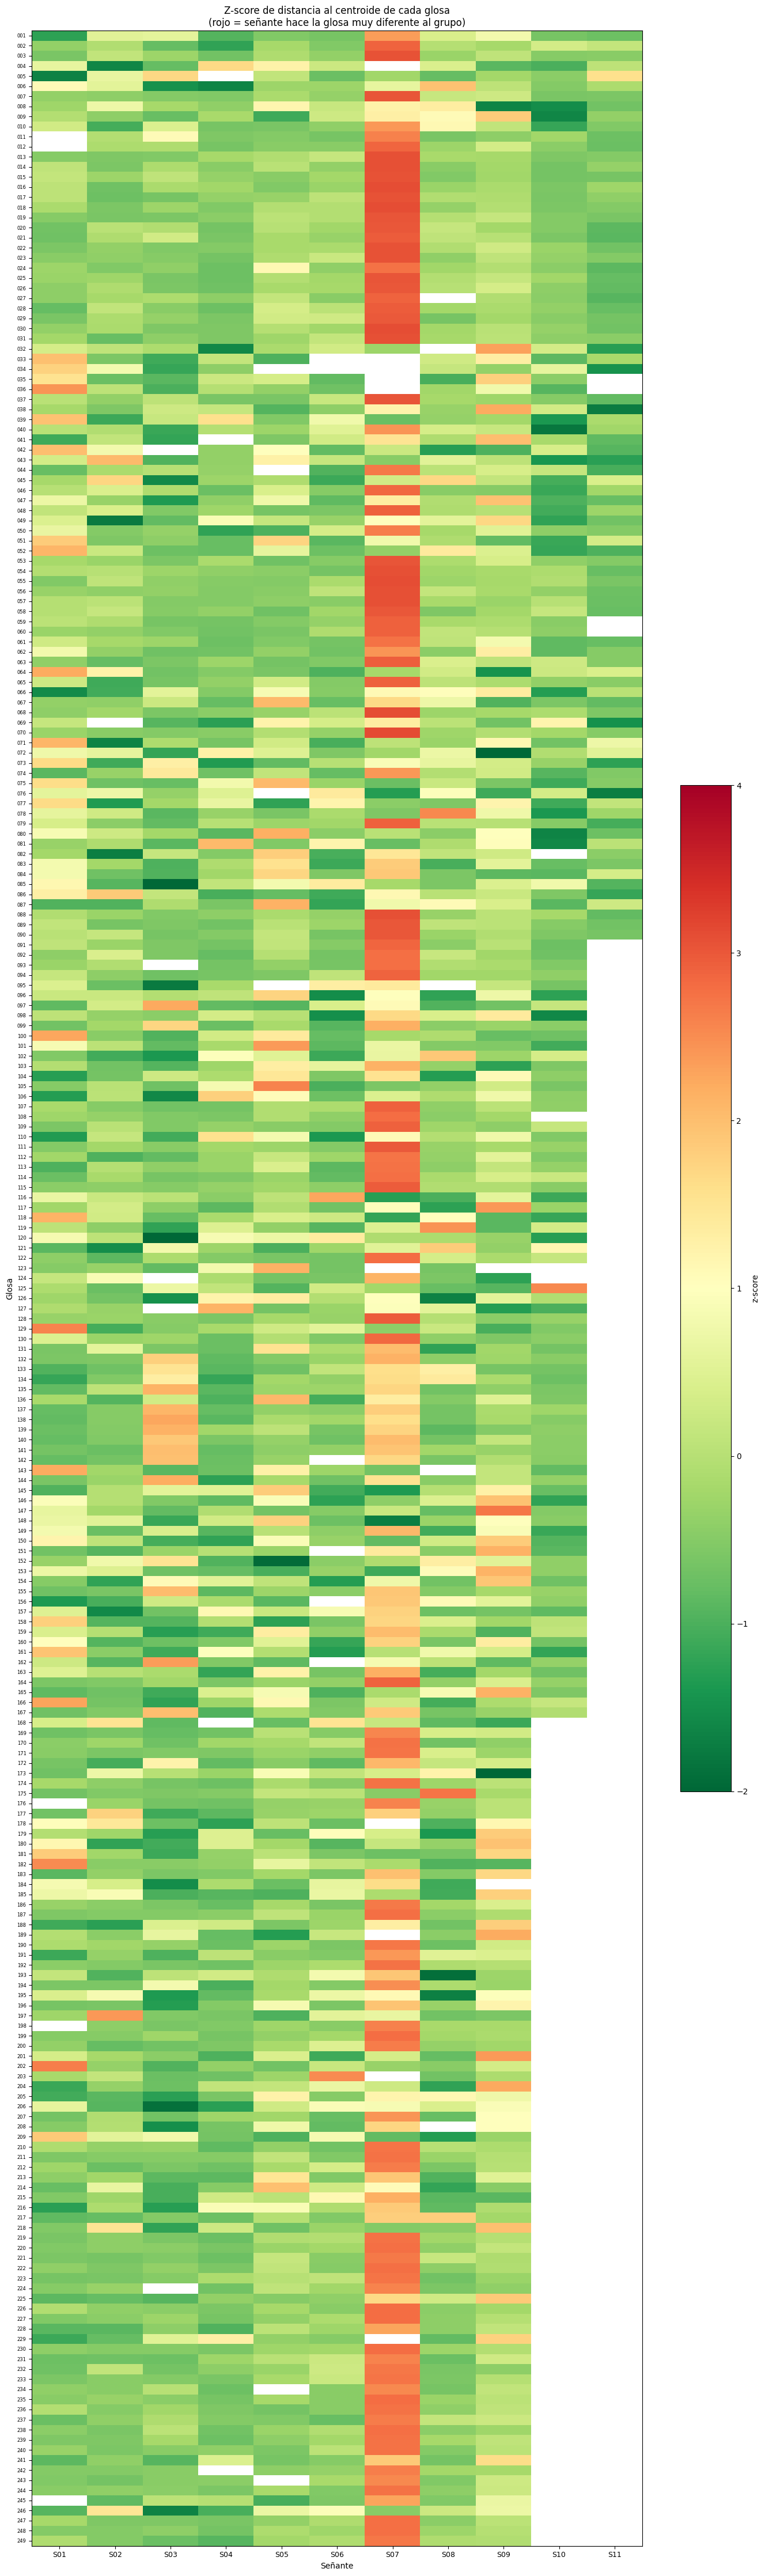

In [20]:
# Celda — heatmap z-score: filas=glosas, columnas=señantes

pivot = df_outliers.pivot_table(
    index="glosa", columns="speaker", values="z_score", aggfunc="first"
)

fig, ax = plt.subplots(figsize=(14, max(6, len(pivot) * 0.18)))

im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn_r",
               vmin=-2, vmax=4)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"S{s}" for s in pivot.columns], fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=6)
ax.set_xlabel("Señante")
ax.set_ylabel("Glosa")
ax.set_title("Z-score de distancia al centroide de cada glosa\n"
             "(rojo = señante hace la glosa muy diferente al grupo)", fontsize=12)

plt.colorbar(im, ax=ax, shrink=0.4, label="z-score")
plt.tight_layout()
plt.savefig("heatmap_outlier_por_glosa.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
# Celda — aplicar filtros y reportar cuántos datos quedan

EXCLUDE_SPEAKERS = ["07"]
Z_THRESH_REMOVE  = 1.5

# ── Estado original ───────────────────────────────────────────────────────────
total_original = len(df)
print(f"Videos originales:          {total_original}")

# ── Paso 1: eliminar señante 07 completamente ─────────────────────────────────
df_clean = df[~df["_speaker"].isin(EXCLUDE_SPEAKERS)].copy()
removed_sp = total_original - len(df_clean)
print(f"\nEliminados por señante {EXCLUDE_SPEAKERS}: -{removed_sp}")
print(f"Videos tras eliminar S07:   {len(df_clean)}")

# Reconstruir arrays sin S07
mask_no07   = ~np.isin(speakers, EXCLUDE_SPEAKERS)
X_c         = X[mask_no07]
glosas_c    = glosas[mask_no07]
speakers_c  = speakers[mask_no07]

# ── Paso 2: calcular z-scores sin S07 ────────────────────────────────────────
records_c = []
for g in sorted(np.unique(glosas_c)):
    mask_g = glosas_c == g
    X_g    = X_c[mask_g]
    sps_g  = speakers_c[mask_g]

    if len(X_g) < 3:
        continue

    centroid = X_g.mean(axis=0)
    dists    = np.linalg.norm(X_g - centroid, axis=1)
    mean_d   = dists.mean()
    std_d    = dists.std()

    for sp, d in zip(sps_g, dists):
        records_c.append({
            "glosa":   g,
            "speaker": sp,
            "z_score": (d - mean_d) / (std_d + 1e-8),
        })

df_z = pd.DataFrame(records_c)

# ── Paso 3: identificar pares (glosa, señante) a eliminar por z > threshold ───
to_remove = df_z[df_z["z_score"] > Z_THRESH_REMOVE][["glosa", "speaker"]]
to_remove_set = set(zip(to_remove["glosa"], to_remove["speaker"]))

removed_z = len(to_remove_set)
print(f"\nPares (glosa, señante) con z > {Z_THRESH_REMOVE}: -{removed_z}")

# ── Paso 4: aplicar filtro z sobre df_clean ───────────────────────────────────
keep_mask = [
    (row["glosa"], row["_speaker"]) not in to_remove_set
    for _, row in df_clean.iterrows()
]
df_final = df_clean[keep_mask]

removed_z_videos = len(df_clean) - len(df_final)
print(f"Videos eliminados por z:    -{removed_z_videos}")
print(f"\nVideos finales:              {len(df_final)}")
print(f"Reducción total:            -{total_original - len(df_final)} "
      f"({(total_original - len(df_final)) / total_original * 100:.1f}%)")

# ── Desglose por split (con los mismos speakers que antes, sin S07) ───────────
val_speakers_new  = ["08"]
test_speakers_new = ["09"]
train_speakers_new = [s for s in df_final["_speaker"].unique()
                      if s not in val_speakers_new + test_speakers_new]

n_train = df_final[df_final["_speaker"].isin(train_speakers_new)].shape[0]
n_val   = df_final[df_final["_speaker"].isin(val_speakers_new)].shape[0]
n_test  = df_final[df_final["_speaker"].isin(test_speakers_new)].shape[0]

print(f"\nDesglose por split:")
print(f"  train ({train_speakers_new}): {n_train}")
print(f"  val   ({val_speakers_new}):         {n_val}")
print(f"  test  ({test_speakers_new}):         {n_test}")

# ── Cobertura de glosas por split ─────────────────────────────────────────────
glosas_train = set(df_final[df_final["_speaker"].isin(train_speakers_new)]["glosa"])
glosas_val   = set(df_final[df_final["_speaker"].isin(val_speakers_new)]["glosa"])
glosas_test  = set(df_final[df_final["_speaker"].isin(test_speakers_new)]["glosa"])
glosas_total = set(df_final["glosa"])

print(f"\nCobertura de glosas:")
print(f"  Glosas únicas en dataset final: {len(glosas_total)}")
print(f"  Glosas en val  cubiertas por train: "
      f"{len(glosas_val & glosas_train)}/{len(glosas_val)}")
print(f"  Glosas en test cubiertas por train: "
      f"{len(glosas_test & glosas_train)}/{len(glosas_test)}")

missing_val  = glosas_val  - glosas_train
missing_test = glosas_test - glosas_train
if missing_val:
    print(f"  ⚠ Glosas en val sin ver en train:  {sorted(missing_val)}")
if missing_test:
    print(f"  ⚠ Glosas en test sin ver en train: {sorted(missing_test)}")

# ── Distribución de z removidos por señante ───────────────────────────────────
print(f"\nVideos eliminados por z — distribución por señante:")
print(to_remove.groupby("speaker").size().sort_values(ascending=False).to_string())

Videos originales:          2447

Eliminados por señante ['07']: -240
Videos tras eliminar S07:   2207

Pares (glosa, señante) con z > 1.5: -233
Videos eliminados por z:    -233

Videos finales:              1974
Reducción total:            -473 (19.3%)

Desglose por split:
  train (['01', '02', '04', '05', '06', '10', '11', '03']): 1542
  val   (['08']):         226
  test  (['09']):         206

Cobertura de glosas:
  Glosas únicas en dataset final: 249
  Glosas en val  cubiertas por train: 226/226
  Glosas en test cubiertas por train: 206/206

Videos eliminados por z — distribución por señante:
speaker
01    62
09    41
05    28
03    24
02    21
04    19
08    18
06    13
10     4
11     3


In [24]:
print("Columnas en df_final:")
print(df_final.columns.tolist())
print(f"\nShape: {df_final.shape}")
print(f"\nEjemplo fila 0:")
print(df_final.iloc[0].drop("keypoints"))

Columnas en df_final:
['glosa', 'intento', 'video_id', 'video_path', 'fps', 'total_frames', 'width', 'height', 'keypoints', 'person_detected', '_speaker']

Shape: (1974, 11)

Ejemplo fila 0:
glosa                                                            001
intento                                                        01001
video_id                                                   001_01001
video_path                                 MSLwords1/001/01001/1.mov
fps                                                             30.0
total_frames                                                      70
width                                                            640
height                                                           480
person_detected    b"\x93NUMPY\x01\x00v\x00{'descr': '|b1', 'fort...
_speaker                                                          01
Name: 0, dtype: object


In [ ]:
# Celda — guardar parquet filtrado

OUTPUT_PATH = "../corpus_LSM_esp/lsm_dataset_filtered.parquet"

df_final.drop(columns=["_speaker"], inplace=False).to_parquet(
    OUTPUT_PATH, index=False
)

print(f"Guardado: {OUTPUT_PATH}")
print(f"  Filas:   {len(df_final)}")
print(f"  Columnas: {list(df_final.columns)}")